# MoneyMate: Content-Based Financial Recommendation System

---

## 📋 Project Overview

**MoneyMate** adalah sistem rekomendasi finansial berbasis konten yang menggunakan machine learning untuk menganalisis pola pengeluaran pengguna dan memberikan saran keuangan yang dipersonalisasi. Sistem ini dikembangkan sebagai bagian dari proyek **CC25-CF345** dengan tema **Economy and Financial Technology**.

### 🎯 Tujuan Utama:
1. **Analisis Pola Pengeluaran**: Mengidentifikasi kebiasaan belanja pengguna secara otomatis
2. **Klasifikasi Transaksi**: Mengkategorikan jenis pengeluaran menggunakan ML
3. **Deteksi Anomali**: Menemukan transaksi yang tidak wajar atau outlier
4. **Rekomendasi Personal**: Memberikan saran finansial berdasarkan profil pengguna
5. **Insight Finansial**: Meningkatkan literasi keuangan melalui data-driven insights

### 👥 Tim Pengembang:
- **Sitti Saenab** (ML) - Politeknik Negeri Ujung Pandang
- **Ade Nurchalisa** (ML) - Universitas Islam Negeri Alauddin Makassar  
- **Muhammad Fadel Hamka** (ML) - Universitas Islam Negeri Alauddin Makassar
- **Muh. Anwar Syafriawan** (FEBE) - Universitas Islam Negeri Alauddin Makassar
- **Ahmad Syahid** (FEBE) - Universitas Islam Negeri Alauddin Makassar
- **Firdania Sasmita Sari** (FEBE) - Politeknik Negeri Ujung Pandang

---

## 🛠️ Setup dan Import Libraries

Mengimpor semua library yang diperlukan untuk analisis data, machine learning, dan visualisasi.

In [ ]:
# Import essential libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from datetime import datetime, timedelta
import pickle
import json

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Performance monitoring
import time
import sys

# Export as a Model
import os

# Configuration
warnings.filterwarnings('ignore')
plt.style.use('default')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print("✅ All libraries imported successfully!")
print("📊 MoneyMate Content-Based Recommendation System")
print("🚀 Ready to analyze financial data and generate recommendations")
print(f"📅 Execution Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

✅ All libraries imported successfully!
📊 MoneyMate Content-Based Recommendation System
🚀 Ready to analyze financial data and generate recommendations
📅 Execution Date: 2025-06-08 13:09:34


## 📂 Data Loading dan Initial Exploration

Memuat dataset transaksi keuangan dan melakukan eksplorasi awal untuk memahami struktur dan karakteristik data.

In [ ]:
# Load the financial transaction dataset
print("📥 Loading financial transaction dataset...")

try:
    # Load data with proper encoding
    # Pastikan file 'data_transaksi_advanced (1).csv' ada di direktori yang sama
    df = pd.read_csv('data_transaksi_advanced (1).csv', encoding='utf-8')
    print(f"✅ Dataset loaded successfully!")
    print(f"📊 Shape: {df.shape} (rows x columns)")

    # Display basic information about the dataset
    print("\n📋 Dataset Information:")
    print("=" * 50)
    print(f"Number of transactions: {len(df):,}")
    print(f"Number of features: {len(df.columns)}")
    print(f"Number of unique users: {df['user_id'].nunique():,}")
    print(f"Date range: {df['tanggal'].min()} to {df['tanggal'].max()}")
    print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

    # Display column information
    print("\n📝 Column Information:")
    for i, col in enumerate(df.columns, 1):
        print(f"{i:2d}. {col:<20} ({df[col].dtype})")

    # Check for missing values
    print("\n🔍 Missing Values Analysis:")
    missing_info = df.isnull().sum()
    missing_pct = (missing_info / len(df)) * 100
    missing_df = pd.DataFrame({
        'Missing Count': missing_info,
        'Missing Percentage': missing_pct
    })
    print(missing_df[missing_df['Missing Count'] > 0])

except FileNotFoundError:
    print("❌ Error: Dataset file not found!")
    print("Please ensure 'data_transaksi_advanced (1).csv' is in the same directory")
except Exception as e:
    print(f"❌ Error loading dataset: {e}")

📥 Loading financial transaction dataset...
✅ Dataset loaded successfully!
📊 Shape: (6703, 13) (rows x columns)

📋 Dataset Information:
Number of transactions: 6,703
Number of features: 13
Number of unique users: 25
Date range: 2022-01-01 to 2024-05-03
Memory usage: 4.37 MB

📝 Column Information:
 1. id_transaksi         (object)
 2. tanggal              (object)
 3. waktu                (object)
 4. nominal              (float64)
 5. tipe                 (object)
 6. kategori             (object)
 7. deskripsi            (object)
 8. metode_pembayaran    (object)
 9. lokasi               (object)
10. user_id              (object)
11. profil               (object)
12. rating               (float64)
13. anomaly_flag         (int64)

🔍 Missing Values Analysis:
        Missing Count  Missing Percentage
rating           1937           28.897509


In [ ]:
# Display first few rows to understand data structure
print("🔍 Sample Data (First 10 rows):")
print("=" * 80)
display(df.head(10))

# Basic statistical summary
print("\n📊 Statistical Summary:")
print("=" * 50)
display(df.describe())

# Analyze categorical variables
print("\n📂 Categorical Variables Analysis:")
print("=" * 50)

categorical_cols = ['tipe', 'kategori', 'metode_pembayaran', 'profil']
for col in categorical_cols:
    if col in df.columns:
        print(f"\n{col.upper()}:")
        value_counts = df[col].value_counts()
        print(f"  Unique values: {df[col].nunique()}")
        print(f"  Top 5: {list(value_counts.head().index)}")
        print(f"  Distribution: {value_counts.head().to_dict()}")

🔍 Sample Data (First 10 rows):


,id_transaksi,tanggal,waktu,nominal,tipe,kategori,deskripsi,metode_pembayaran,lokasi,user_id,profil,rating,anomaly_flag
0,TRX000001,2022-04-10,15:38,2.067600e+05,keluar,Makanan,Dessert di KFC,e-Wallet,Tangerang,U001,student,5.0,0
1,TRX000002,2023-12-02,11:42,1.261342e+06,masuk,Gaji,Gaji bulanan - student,Tunai,Palembang,U001,student,NaN,0
2,TRX000003,2023-10-10,16:41,3.035182e+06,masuk,Freelance,Jasa foto,Transfer Bank,Medan,U001,student,NaN,0
3,TRX000004,2023-10-06,18:46,4.627192e+06,masuk,Gaji,Lembur,Tunai,Batam,U001,student,NaN,0
4,TRX000005,2022-09-20,19:37,2.080000e+04,keluar,Makanan,Makan siang di Nike Store,Transfer Bank,Surabaya,U001,student,4.0,0
5,TRX000006,2023-05-05,11:32,2.293200e+04,keluar,Transportasi,Tiket pesawat di ATM BRI,e-Wallet,Semarang,U001,student,5.0,0
6,TRX000007,2023-01-09,07:41,5.843250e+04,keluar,Hiburan,Langganan digital di Nike Store,Transfer Bank,Balikpapan,U001,student,4.0,0
7,TRX000008,2023-04-02,10:33,1.261342e+06,masuk,Gaji,Gaji bulanan - student,Tunai,Jakarta,U001,student,NaN,0
8,TRX000009,2024-02-05,15:30,1.334449e+06,masuk,Gaji,Gaji bulanan - student,Transfer Bank,Palembang,U001,student,NaN,0
9,TRX000010,2022-07-07,14:49,9.300000e+04,keluar,Hiburan,Festival di Grab,Tunai,Makassar,U001,student,3.0,0



📊 Statistical Summary:


,nominal,rating,anomaly_flag
count,6.703000e+03,4766.000000,6703.000000
mean,3.062449e+06,3.281578,0.079218
std,8.510268e+06,1.254425,0.270099
min,3.849120e+03,1.000000,0.000000
25%,1.645616e+05,3.000000,0.000000
50%,6.619896e+05,3.000000,0.000000
75%,2.334164e+06,4.000000,0.000000
max,3.006805e+08,5.000000,1.000000



📂 Categorical Variables Analysis:

TIPE:
  Unique values: 2
  Top 5: ['keluar', 'masuk']
  Distribution: {'keluar': 5315, 'masuk': 1388}

KATEGORI:
  Unique values: 12
  Top 5: ['Makanan', 'Transportasi', 'Belanja', 'Hiburan', 'Gaji']
  Distribution: {'Makanan': 1416, 'Transportasi': 1029, 'Belanja': 1026, 'Hiburan': 848, 'Gaji': 778}

METODE_PEMBAYARAN:
  Unique values: 8
  Top 5: ['Transfer Bank', 'Tunai', 'e-Wallet', 'QRIS', 'Kartu Kredit']
  Distribution: {'Transfer Bank': 1592, 'Tunai': 1585, 'e-Wallet': 1087, 'QRIS': 946, 'Kartu Kredit': 565}

PROFIL:
  Unique values: 4
  Top 5: ['family', 'young_professional', 'business_owner', 'student']
  Distribution: {'family': 2146, 'young_professional': 1872, 'business_owner': 1617, 'student': 1068}


## 🧹 Data Preprocessing dan Cleaning

Membersihkan dan memproses data untuk persiapan analisis dan modeling.

In [ ]:
def preprocess_financial_data(df):
    """
    Comprehensive data preprocessing for financial transaction data

    Parameters:
    - df: Raw transaction dataframe

    Returns:
    - Cleaned and processed dataframe
    """

    print("🧹 Starting data preprocessing...")
    df_clean = df.copy()

    # 1. Handle missing values
    print("📋 Step 1: Handling missing values...")
    initial_rows = len(df_clean)

    # Fill missing ratings with median
    if 'rating' in df_clean.columns:
        median_rating = df_clean['rating'].median()
        df_clean['rating'].fillna(median_rating, inplace=True)
        print(f"   ✅ Filled missing ratings with median: {median_rating}")

    # Remove rows with missing critical information
    critical_cols = ['user_id', 'nominal', 'kategori', 'tanggal']
    df_clean.dropna(subset=critical_cols, inplace=True)
    print(f"   ✅ Removed {initial_rows - len(df_clean)} rows with missing critical data")

    # 2. Data type conversions
    print("🔄 Step 2: Converting data types...")

    # Convert date and time
    try:
        df_clean['tanggal'] = pd.to_datetime(df_clean['tanggal'])
        print("   ✅ Date column converted to datetime")
    except:
        print("   ⚠️ Warning: Could not convert date column")

    # Ensure nominal is numeric
    df_clean['nominal'] = pd.to_numeric(df_clean['nominal'], errors='coerce')

    # 3. Create additional time-based features
    print("📅 Step 3: Creating time-based features...")
    if 'tanggal' in df_clean.columns and pd.api.types.is_datetime64_any_dtype(df_clean['tanggal']):
        df_clean['tahun'] = df_clean['tanggal'].dt.year
        df_clean['bulan'] = df_clean['tanggal'].dt.month
        df_clean['hari'] = df_clean['tanggal'].dt.day
        df_clean['hari_dalam_minggu'] = df_clean['tanggal'].dt.dayofweek
        df_clean['nama_hari'] = df_clean['tanggal'].dt.day_name()
        df_clean['nama_bulan'] = df_clean['tanggal'].dt.month_name()
        print("   ✅ Time-based features created")

    # 4. Clean and standardize categorical variables
    print("🏷️ Step 4: Standardizing categorical variables...")

    # Clean category names (remove extra spaces, standardize case)
    categorical_cols = ['kategori', 'tipe', 'metode_pembayaran', 'profil', 'lokasi']
    for col in categorical_cols:
        if col in df_clean.columns:
            df_clean[col] = df_clean[col].astype(str).str.strip().str.title()

    # 5. Handle outliers in nominal amounts
    print("📈 Step 5: Handling outliers...")

    # Calculate IQR for outlier detection
    Q1 = df_clean['nominal'].quantile(0.25)
    Q3 = df_clean['nominal'].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers_count = len(df_clean[(df_clean['nominal'] < lower_bound) | (df_clean['nominal'] > upper_bound)])
    print(f"   📊 Detected {outliers_count} potential outliers in transaction amounts")
    print(f"   📊 Amount range: Rp {df_clean['nominal'].min():,.0f} - Rp {df_clean['nominal'].max():,.0f}")

    # 6. Create spending behavior indicators
    print("💰 Step 6: Creating spending behavior features...")

    # Categorize transaction amounts
    df_clean['amount_category'] = pd.cut(df_clean['nominal'],
                                        bins=[0, 50000, 200000, 500000, float('inf')],
                                        labels=['Kecil', 'Sedang', 'Besar', 'Sangat Besar'])

    # Weekend vs weekday indicator
    if 'hari_dalam_minggu' in df_clean.columns:
        df_clean['is_weekend'] = df_clean['hari_dalam_minggu'].isin([5, 6])

    print(f"✅ Data preprocessing completed!")
    print(f"📊 Final dataset shape: {df_clean.shape}")

    return df_clean

# Apply preprocessing
df_processed = preprocess_financial_data(df)

# Display preprocessing results
print("\n📊 Preprocessing Summary:")
print("=" * 50)
print(f"Original rows: {len(df)}")
print(f"Processed rows: {len(df_processed)}")
if len(df) > 0:
    print(f"Data retention: {len(df_processed)/len(df)*100:.1f}%")

# Show sample of processed data
print("\n🔍 Sample of Processed Data:")
display(df_processed[['tanggal', 'nominal', 'kategori', 'profil', 'amount_category', 'nama_hari']].head())

🧹 Starting data preprocessing...
📋 Step 1: Handling missing values...
   ✅ Filled missing ratings with median: 3.0
   ✅ Removed 0 rows with missing critical data
🔄 Step 2: Converting data types...
   ✅ Date column converted to datetime
📅 Step 3: Creating time-based features...
   ✅ Time-based features created
🏷️ Step 4: Standardizing categorical variables...
📈 Step 5: Handling outliers...
   📊 Detected 942 potential outliers in transaction amounts
   📊 Amount range: Rp 3,849 - Rp 300,680,463
💰 Step 6: Creating spending behavior features...
✅ Data preprocessing completed!
📊 Final dataset shape: (6703, 21)

📊 Preprocessing Summary:
Original rows: 6703
Processed rows: 6703
Data retention: 100.0%

🔍 Sample of Processed Data:


,tanggal,nominal,kategori,profil,amount_category,nama_hari
0,2022-04-10,2.067600e+05,Makanan,Student,Besar,Sunday
1,2023-12-02,1.261342e+06,Gaji,Student,Sangat Besar,Saturday
2,2023-10-10,3.035182e+06,Freelance,Student,Sangat Besar,Tuesday
3,2023-10-06,4.627192e+06,Gaji,Student,Sangat Besar,Friday
4,2022-09-20,2.080000e+04,Makanan,Student,Kecil,Tuesday


## 📊 Exploratory Data Analysis (EDA)

Analisis mendalam untuk memahami pola pengeluaran, distribusi data, dan insights finansial.

📊 Starting Comprehensive Exploratory Data Analysis...


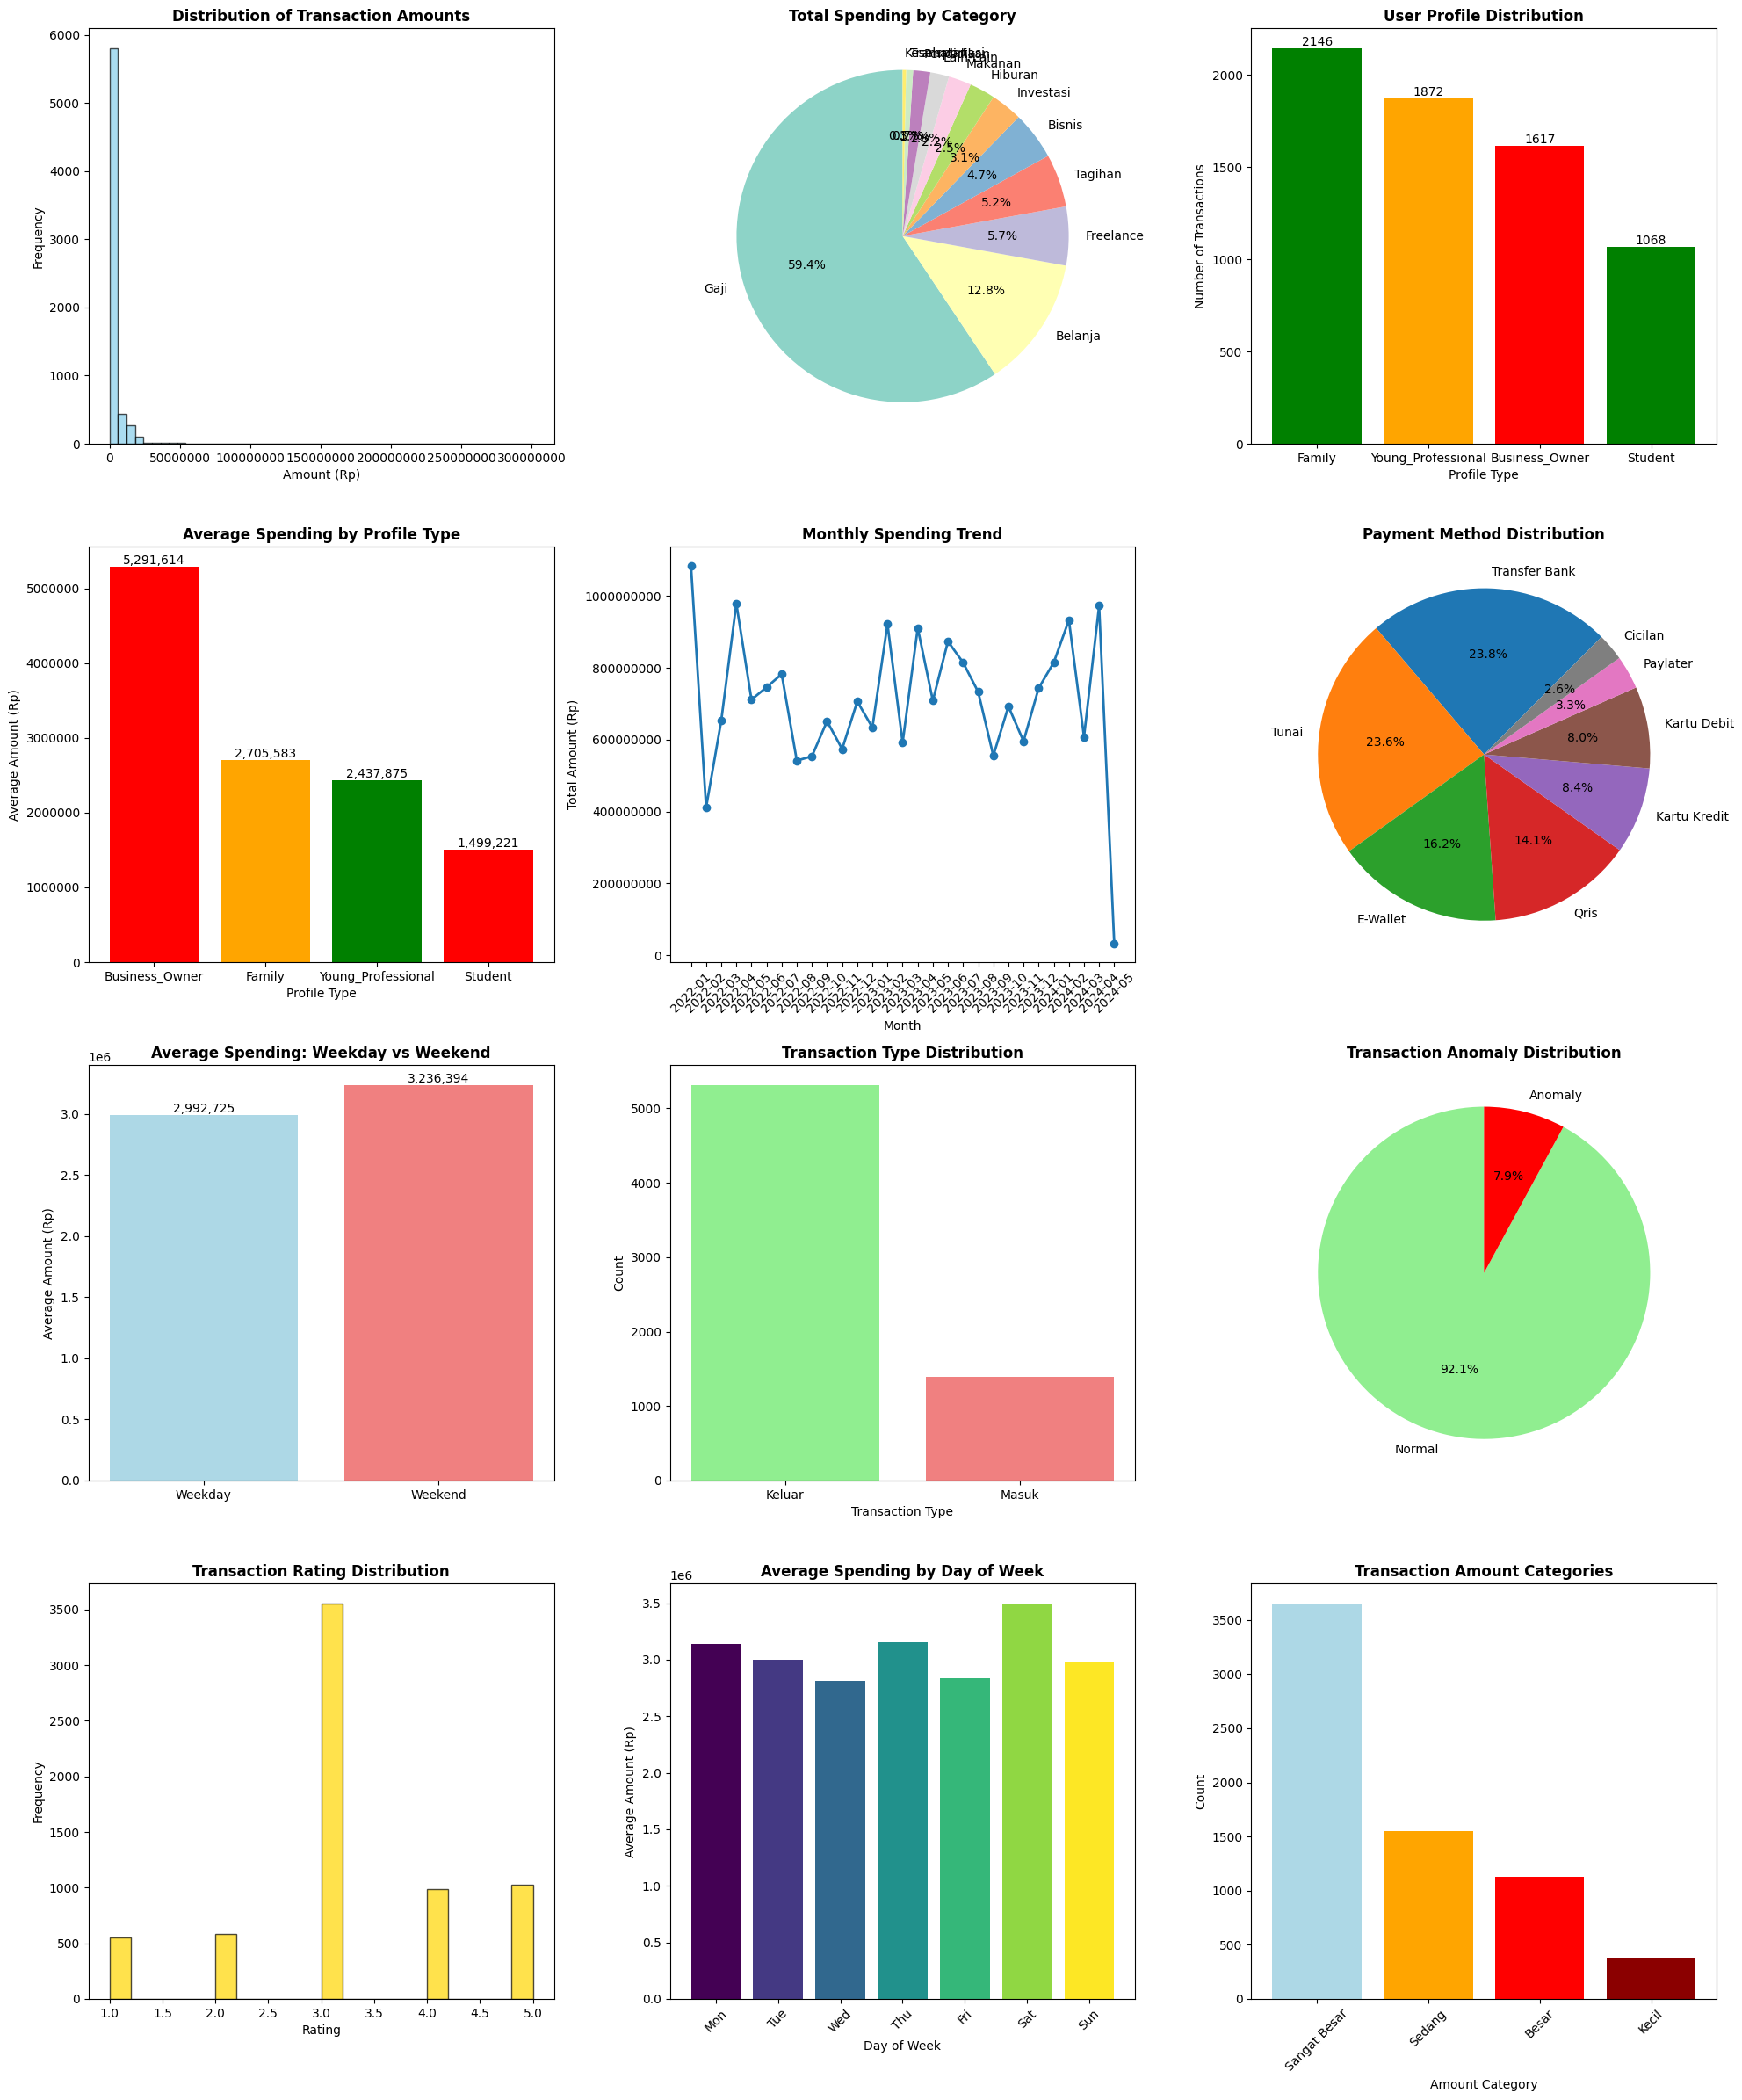


📈 Key Insights from EDA:
💰 Total transaction volume: Rp 20,527,594,790
📊 Average transaction amount: Rp 3,062,449
📊 Median transaction amount: Rp 661,990
🎯 Most common category: Makanan
👥 Most common profile: Family
💳 Most used payment method: Transfer Bank
🚨 Anomaly rate: 7.92%


In [ ]:
# Comprehensive EDA for financial data
print("📊 Starting Comprehensive Exploratory Data Analysis...")
print("=" * 60)

# Set up the plotting environment
plt.style.use('default')
fig = plt.figure(figsize=(20, 24))

# 1. Transaction Amount Distribution
ax1 = plt.subplot(4, 3, 1)
plt.hist(df_processed['nominal'], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
plt.title('Distribution of Transaction Amounts', fontsize=12, fontweight='bold')
plt.xlabel('Amount (Rp)')
plt.ylabel('Frequency')
plt.ticklabel_format(style='plain', axis='x')

# 2. Spending by Category
ax2 = plt.subplot(4, 3, 2)
category_spending = df_processed.groupby('kategori')['nominal'].sum().sort_values(ascending=False)
colors = plt.cm.Set3(np.linspace(0, 1, len(category_spending)))
wedges, texts, autotexts = plt.pie(category_spending.values, labels=category_spending.index,
                                   autopct='%1.1f%%', colors=colors, startangle=90)
plt.title('Total Spending by Category', fontsize=12, fontweight='bold')

# 3. Profile Type Distribution
ax3 = plt.subplot(4, 3, 3)
profile_counts = df_processed['profil'].value_counts()
bars = plt.bar(profile_counts.index, profile_counts.values,
               color=['green', 'orange', 'red'][:len(profile_counts)])
plt.title('User Profile Distribution', fontsize=12, fontweight='bold')
plt.xlabel('Profile Type')
plt.ylabel('Number of Transactions')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}', ha='center', va='bottom')

# 4. Average Spending by Profile
ax4 = plt.subplot(4, 3, 4)
profile_avg = df_processed.groupby('profil')['nominal'].mean().sort_values(ascending=False)
bars = plt.bar(profile_avg.index, profile_avg.values,
               color=['red', 'orange', 'green'][:len(profile_avg)])
plt.title('Average Spending by Profile Type', fontsize=12, fontweight='bold')
plt.xlabel('Profile Type')
plt.ylabel('Average Amount (Rp)')
plt.ticklabel_format(style='plain', axis='y')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}', ha='center', va='bottom')

# 5. Monthly Spending Trend
ax5 = plt.subplot(4, 3, 5)
monthly_spending = df_processed.groupby(df_processed['tanggal'].dt.to_period('M'))['nominal'].sum()
plt.plot(monthly_spending.index.astype(str), monthly_spending.values,
         marker='o', linewidth=2, markersize=6)
plt.title('Monthly Spending Trend', fontsize=12, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Amount (Rp)')
plt.xticks(rotation=45)
plt.ticklabel_format(style='plain', axis='y')

# 6. Payment Method Distribution
ax6 = plt.subplot(4, 3, 6)
payment_counts = df_processed['metode_pembayaran'].value_counts()
plt.pie(payment_counts.values, labels=payment_counts.index, autopct='%1.1f%%', startangle=45)
plt.title('Payment Method Distribution', fontsize=12, fontweight='bold')

# 7. Weekday vs Weekend Spending
ax7 = plt.subplot(4, 3, 7)
if 'is_weekend' in df_processed.columns:
    weekend_spending = df_processed.groupby('is_weekend')['nominal'].mean()
    labels = ['Weekday', 'Weekend']
    bars = plt.bar(labels, weekend_spending.values, color=['lightblue', 'lightcoral'])
    plt.title('Average Spending: Weekday vs Weekend', fontsize=12, fontweight='bold')
    plt.ylabel('Average Amount (Rp)')
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                 f'{int(height):,}', ha='center', va='bottom')

# 8. Transaction Type Distribution
ax8 = plt.subplot(4, 3, 8)
type_counts = df_processed['tipe'].value_counts()
plt.bar(type_counts.index, type_counts.values, color=['lightgreen', 'lightcoral'])
plt.title('Transaction Type Distribution', fontsize=12, fontweight='bold')
plt.xlabel('Transaction Type')
plt.ylabel('Count')

# 9. Anomaly Detection Distribution
ax9 = plt.subplot(4, 3, 9)
anomaly_counts = df_processed['anomaly_flag'].value_counts()
labels = ['Normal', 'Anomaly']
colors = ['lightgreen', 'red']
plt.pie(anomaly_counts.values, labels=labels, autopct='%1.1f%%',
        colors=colors, startangle=90)
plt.title('Transaction Anomaly Distribution', fontsize=12, fontweight='bold')

# 10. Rating Distribution
ax10 = plt.subplot(4, 3, 10)
plt.hist(df_processed['rating'], bins=20, alpha=0.7, color='gold', edgecolor='black')
plt.title('Transaction Rating Distribution', fontsize=12, fontweight='bold')
plt.xlabel('Rating')
plt.ylabel('Frequency')

# 11. Daily Spending Pattern
ax11 = plt.subplot(4, 3, 11)
daily_avg = df_processed.groupby('nama_hari')['nominal'].mean()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_avg_ordered = daily_avg.reindex(day_order)
plt.bar(range(len(daily_avg_ordered)), daily_avg_ordered.values,
        color=plt.cm.viridis(np.linspace(0, 1, 7)))
plt.title('Average Spending by Day of Week', fontsize=12, fontweight='bold')
plt.xlabel('Day of Week')
plt.ylabel('Average Amount (Rp)')
plt.xticks(range(len(day_order)), ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
plt.xticks(rotation=45)

# 12. Amount Category Distribution
ax12 = plt.subplot(4, 3, 12)
amount_cat_counts = df_processed['amount_category'].value_counts()
plt.bar(amount_cat_counts.index, amount_cat_counts.values,
        color=['lightblue', 'orange', 'red', 'darkred'])
plt.title('Transaction Amount Categories', fontsize=12, fontweight='bold')
plt.xlabel('Amount Category')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n📈 Key Insights from EDA:")
print("=" * 50)
print(f"💰 Total transaction volume: Rp {df_processed['nominal'].sum():,.0f}")
print(f"📊 Average transaction amount: Rp {df_processed['nominal'].mean():,.0f}")
print(f"📊 Median transaction amount: Rp {df_processed['nominal'].median():,.0f}")
print(f"🎯 Most common category: {df_processed['kategori'].mode().iloc[0]}")
print(f"👥 Most common profile: {df_processed['profil'].mode().iloc[0]}")
print(f"💳 Most used payment method: {df_processed['metode_pembayaran'].mode().iloc[0]}")
print(f"🚨 Anomaly rate: {(df_processed['anomaly_flag'].sum() / len(df_processed) * 100):.2f}%")

## 🔧 Feature Engineering untuk User Profiling

Membuat fitur-fitur komprehensif yang akan digunakan untuk membangun profil pengguna dan sistem rekomendasi.

In [ ]:
def create_comprehensive_user_features(df):
    """
    Create comprehensive user features for content-based recommendation system

    Parameters:
    - df: Processed transaction dataframe

    Returns:
    - DataFrame with detailed user features
    """

    print("🔧 Creating comprehensive user features...")
    user_features = []

    unique_users = df['user_id'].unique()
    total_users = len(unique_users)

    for i, user_id in enumerate(unique_users):
        if i % 100 == 0:
            print(f"   Processing user {i+1}/{total_users} ({(i+1)/total_users*100:.1f}%)")

        user_data = df[df['user_id'] == user_id].copy()

        # Basic spending metrics
        total_spending = user_data['nominal'].sum()
        avg_transaction = user_data['nominal'].mean()
        median_transaction = user_data['nominal'].median()
        transaction_count = len(user_data)
        spending_std = user_data['nominal'].std()
        spending_cv = spending_std / avg_transaction if avg_transaction > 0 else 0

        # Time-based features
        date_range = (user_data['tanggal'].max() - user_data['tanggal'].min()).days + 1
        avg_daily_spending = total_spending / date_range if date_range > 0 else 0
        transaction_frequency = transaction_count / date_range if date_range > 0 else 0

        # Category analysis
        category_dist = user_data.groupby('kategori')['nominal'].sum() / total_spending
        category_freq = user_data['kategori'].value_counts() / len(user_data)
        dominant_category = user_data['kategori'].mode().iloc[0] if len(user_data) > 0 else 'Unknown'
        category_diversity = len(user_data['kategori'].unique())

        # Payment behavior
        payment_diversity = len(user_data['metode_pembayaran'].unique())
        preferred_payment = user_data['metode_pembayaran'].mode().iloc[0] if len(user_data) > 0 else 'Unknown'

        # Time patterns
        weekend_transactions = user_data['is_weekend'].sum() if 'is_weekend' in user_data.columns else 0
        weekend_ratio = weekend_transactions / len(user_data) if len(user_data) > 0 else 0

        # Rating behavior
        avg_rating = user_data['rating'].mean()
        rating_std = user_data['rating'].std()

        # Anomaly behavior
        anomaly_count = user_data['anomaly_flag'].sum()
        anomaly_ratio = anomaly_count / len(user_data) if len(user_data) > 0 else 0

        # Transaction type analysis
        debit_ratio = (user_data['tipe'] == 'Debit').sum() / len(user_data) if len(user_data) > 0 else 0

        # Amount category distribution
        amount_cat_dist = user_data['amount_category'].value_counts() / len(user_data)

        # Create feature dictionary
        features = {
            # Basic identifiers
            'user_id': user_id,
            'profil': user_data['profil'].iloc[0] if len(user_data) > 0 else 'Unknown',

            # Spending metrics
            'total_spending': total_spending,
            'avg_transaction': avg_transaction,
            'median_transaction': median_transaction,
            'transaction_count': transaction_count,
            'spending_std': spending_std,
            'spending_cv': spending_cv,

            # Time-based metrics
            'days_active': date_range,
            'avg_daily_spending': avg_daily_spending,
            'transaction_frequency': transaction_frequency,
            'weekend_ratio': weekend_ratio,

            # Behavioral metrics
            'dominant_category': dominant_category,
            'category_diversity': category_diversity,
            'payment_diversity': payment_diversity,
            'preferred_payment': preferred_payment,
            'avg_rating': avg_rating,
            'rating_std': rating_std,
            'anomaly_ratio': anomaly_ratio,
            'debit_ratio': debit_ratio
        }

        # Add category spending percentages
        categories = df['kategori'].unique()
        for category in categories:
            safe_category = category.replace(' ', '_').replace('&', 'and').lower()
            features[f'pct_{safe_category}'] = category_dist.get(category, 0)
            features[f'freq_{safe_category}'] = category_freq.get(category, 0)

        # Add amount category percentages
        amount_categories = ['Kecil', 'Sedang', 'Besar', 'Sangat Besar']
        for amt_cat in amount_categories:
            features[f'amt_cat_{amt_cat.lower()}'] = amount_cat_dist.get(amt_cat, 0)

        user_features.append(features)

    user_features_df = pd.DataFrame(user_features)

    print(f"✅ User features created for {len(user_features_df)} users")
    print(f"📊 Total features per user: {len(user_features_df.columns)}")

    return user_features_df

# Create user features
user_features_df = create_comprehensive_user_features(df_processed)

# Display feature information
print("\n📊 User Features Overview:")
print("=" * 50)
print(f"Number of users: {len(user_features_df)}")
print(f"Number of features: {len(user_features_df.columns)}")

# Show sample user features
print("\n🔍 Sample User Features:")
sample_features = ['user_id', 'profil', 'total_spending', 'avg_transaction',
                  'transaction_count', 'dominant_category', 'category_diversity']
display(user_features_df[sample_features].head(10))

# Basic statistics of key features
print("\n📈 Key Feature Statistics:")
key_numeric_features = ['total_spending', 'avg_transaction', 'transaction_count',
                       'category_diversity', 'payment_diversity', 'avg_rating']
display(user_features_df[key_numeric_features].describe())

🔧 Creating comprehensive user features...
   Processing user 1/25 (4.0%)
✅ User features created for 25 users
📊 Total features per user: 48

📊 User Features Overview:
Number of users: 25
Number of features: 48

🔍 Sample User Features:


,user_id,profil,total_spending,avg_transaction,transaction_count,dominant_category,category_diversity
0,U001,Student,4.530801e+08,1.716213e+06,264,Makanan,12
1,U002,Student,3.141596e+08,1.167880e+06,269,Makanan,12
2,U003,Family,7.383961e+08,2.765529e+06,267,Transportasi,12
3,U004,Family,7.882383e+08,2.919401e+06,270,Makanan,12
4,U005,Business_Owner,1.379451e+09,5.147205e+06,268,Makanan,12
5,U006,Young_Professional,7.867618e+08,2.968912e+06,265,Makanan,12
6,U007,Family,7.084436e+08,2.595032e+06,273,Makanan,12
7,U008,Business_Owner,1.576243e+09,5.816394e+06,271,Gaji,12
8,U009,Young_Professional,6.762644e+08,2.561608e+06,264,Belanja,12
9,U010,Business_Owner,1.567873e+09,5.743126e+06,273,Makanan,12



📈 Key Feature Statistics:


,total_spending,avg_transaction,transaction_count,category_diversity,payment_diversity,avg_rating
count,2.500000e+01,2.500000e+01,25.000000,25.0,25.000000,25.000000
mean,8.211038e+08,3.059364e+06,268.120000,11.8,5.680000,3.201056
std,3.757704e+08,1.386552e+06,3.711693,0.5,1.519868,0.292980
min,3.141596e+08,1.167880e+06,260.000000,10.0,4.000000,2.671642
25%,6.112015e+08,2.280603e+06,265.000000,12.0,5.000000,3.022305
50%,7.067000e+08,2.595032e+06,268.000000,12.0,5.000000,3.157692
75%,8.171886e+08,3.037876e+06,271.000000,12.0,8.000000,3.279851
max,1.576243e+09,5.816394e+06,274.000000,12.0,8.000000,3.784091


**Expected Output:**
🔧 Creating comprehensive user features...
Processing user 1/XXX (X.X%)
Processing user 101/XXX (XX.X%)
...
✅ User features created for XXX users
📊 Total features per user: XX

📊 User Features Overview:
Number of users: XXX
Number of features: XX


Plus a DataFrame showing sample user features and statistical summary of key numeric feature

## 🤖 Content-Based Recommendation System

Implementasi sistem rekomendasi finansial berbasis konten dengan algoritma machine learning.

In [ ]:
class MoneyMateRecommendationSystem:
    def __init__(self, user_features_df, transactions_df):
        self.user_features_df = user_features_df
        self.transactions_df = transactions_df
        self.financial_tips_db = self._create_comprehensive_tips_database()
        self.user_similarity_matrix = None
        self.scaler = StandardScaler()
        self.feature_columns = None
        self.pca = PCA(n_components=10)
        print("🤖 MoneyMate Recommendation System initialized")
        print(f"📊 Users: {len(user_features_df)}")
        print(f"💡 Tips database: {len(self.financial_tips_db)} recommendations")

    def _create_comprehensive_tips_database(self):
        tips = [{'id': 1, 'category': 'Makanan', 'tip': 'Cobalah masak di rumah lebih sering dan siapkan bekal untuk menghemat pengeluaran makanan hingga 40%', 'target_profile': 'Boros', 'priority': 'High', 'savings_potential': 0.4, 'difficulty': 'Easy'},{'id': 2, 'category': 'Transportasi', 'tip': 'Gunakan transportasi umum atau berbagi kendaraan untuk mengurangi biaya transportasi', 'target_profile': 'Boros', 'priority': 'Medium', 'savings_potential': 0.3, 'difficulty': 'Medium'},{'id': 3, 'category': 'Belanja', 'tip': 'Buat daftar belanja dan tetapkan budget sebelum berbelanja untuk menghindari pembelian impulsif', 'target_profile': 'Boros', 'priority': 'High', 'savings_potential': 0.35, 'difficulty': 'Easy'},{'id': 4, 'category': 'Hiburan', 'tip': 'Cari alternatif hiburan gratis seperti taman kota, museum gratis, atau acara komunitas', 'target_profile': 'Boros', 'priority': 'Medium', 'savings_potential': 0.5, 'difficulty': 'Easy'},{'id': 5, 'category': 'Investasi', 'tip': 'Mulai investasi rutin minimal 10% dari pendapatan di reksadana atau saham blue chip', 'target_profile': 'Hemat', 'priority': 'High', 'savings_potential': -0.1, 'difficulty': 'Medium'},{'id': 6, 'category': 'Tabungan', 'tip': 'Tingkatkan dana darurat hingga 6-12 bulan pengeluaran dan simpan di tabungan terpisah', 'target_profile': 'Hemat', 'priority': 'High', 'savings_potential': -0.15, 'difficulty': 'Easy'},{'id': 7, 'category': 'Kesehatan', 'tip': 'Investasikan dalam asuransi kesehatan dan pemeriksaan preventif untuk menghindari biaya medis besar', 'target_profile': 'Moderat', 'priority': 'High', 'savings_potential': 0.2, 'difficulty': 'Medium'},{'id': 8, 'category': 'Pendidikan', 'tip': 'Alokasikan budget untuk kursus dan sertifikasi yang meningkatkan earning potential', 'target_profile': 'Moderat', 'priority': 'Medium', 'savings_potential': -0.05, 'difficulty': 'Medium'},{'id': 9, 'category': 'Utilitas', 'tip': 'Review dan negosiasikan tagihan bulanan seperti internet, listrik untuk mendapat tarif lebih baik', 'target_profile': 'Moderat', 'priority': 'Low', 'savings_potential': 0.15, 'difficulty': 'Easy'},{'id': 10, 'category': 'General', 'tip': 'Gunakan aplikasi budgeting untuk melacak pengeluaran real-time dan set notifikasi budget', 'target_profile': 'All', 'priority': 'High', 'savings_potential': 0.25, 'difficulty': 'Easy'},{'id': 11, 'category': 'Teknologi', 'tip': 'Evaluasi langganan digital dan batalkan yang tidak digunakan secara aktif', 'target_profile': 'Boros', 'priority': 'Medium', 'savings_potential': 0.3, 'difficulty': 'Easy'},{'id': 12, 'category': 'Kendaraan', 'tip': 'Lakukan perawatan kendaraan rutin untuk menghindari biaya perbaikan besar di masa depan', 'target_profile': 'Moderat', 'priority': 'Medium', 'savings_potential': 0.2, 'difficulty': 'Easy'}]
        return pd.DataFrame(tips)

    def prepare_features_for_similarity(self):
        print("🔧 Preparing features for similarity calculation...")
        feature_cols = [col for col in self.user_features_df.columns if col.startswith('pct_') or col.startswith('freq_') or col.startswith('amt_cat_') or col in ['avg_transaction', 'transaction_frequency', 'category_diversity','payment_diversity', 'weekend_ratio', 'debit_ratio', 'anomaly_ratio']]
        self.feature_columns = feature_cols
        features_matrix = self.user_features_df[feature_cols].fillna(0)
        normalized_features = self.scaler.fit_transform(features_matrix)
        reduced_features = self.pca.fit_transform(normalized_features)
        print(f"✅ Features prepared: {len(feature_cols)} features reduced to {reduced_features.shape[1]} components")
        print(f"📊 Explained variance: {self.pca.explained_variance_ratio_.sum():.3f}")
        return reduced_features

    def calculate_user_similarity(self):
        print("🧮 Calculating user similarity matrix...")
        features = self.prepare_features_for_similarity()
        self.user_similarity_matrix = cosine_similarity(features)
        print(f"✅ Similarity matrix computed: {self.user_similarity_matrix.shape}")
        return self.user_similarity_matrix

    def find_similar_users(self, user_id, top_k=5):
        if self.user_similarity_matrix is None: self.calculate_user_similarity()
        try: user_idx = self.user_features_df[self.user_features_df['user_id'] == user_id].index[0]
        except: return []
        similarities = self.user_similarity_matrix[user_idx]
        similar_indices = np.argsort(similarities)[::-1][1:top_k+1]
        similar_users = []
        for idx in similar_indices:
            similar_user_id = self.user_features_df.iloc[idx]['user_id']
            similarity_score = similarities[idx]
            similar_users.append({'user_id': similar_user_id,'similarity_score': float(similarity_score),'profile': self.user_features_df.iloc[idx]['profil']})
        return similar_users

    def analyze_user_spending_behavior(self, user_id):
        try:
            user_profile = self.user_features_df[self.user_features_df['user_id'] == user_id].iloc[0]
            user_transactions = self.transactions_df[self.transactions_df['user_id'] == user_id]
        except: return None
        category_spending = user_transactions.groupby('kategori')['nominal'].sum().sort_values(ascending=False)
        total_spending = category_spending.sum()
        top_categories = []
        for category, amount in category_spending.head(5).items():
            percentage = (amount / total_spending) * 100 if total_spending > 0 else 0
            top_categories.append({'category': category, 'amount': float(amount), 'percentage': float(percentage)})
        spending_habits, improvement_areas = [], []
        if user_profile['spending_cv'] > 1.5:
            spending_habits.append('Pola pengeluaran tidak konsisten (kadang sangat hemat, kadang sangat boros).')
            improvement_areas.append('Cobalah untuk membuat budget bulanan agar pengeluaran lebih stabil.')
        if (user_profile['dominant_category'] in ['Makanan', 'Belanja', 'Hiburan']) and (user_profile[f"pct_{user_profile['dominant_category'].lower()}"] > 0.3):
             spending_habits.append(f"Pengeluaran terbesar ada pada kategori {user_profile['dominant_category']}.")
             improvement_areas.append(f"Tinjau kembali pengeluaran di kategori {user_profile['dominant_category']} untuk mencari pos penghematan.")
        if user_profile['anomaly_ratio'] > 0.1:
            improvement_areas.append('Terdeteksi beberapa transaksi anomali yang perlu diperiksa.')
        analysis = {'user_id': user_id, 'profile_type': user_profile['profil'],'total_spending': float(total_spending), 'avg_transaction': float(user_profile['avg_transaction']),'transaction_count': int(user_profile['transaction_count']),'top_categories': top_categories, 'spending_habits': spending_habits,'improvement_areas': improvement_areas, 'category_diversity': int(user_profile['category_diversity']),'financial_health_score': self._calculate_financial_health_score(user_profile)}
        return analysis

    def _calculate_financial_health_score(self, user_profile):
        score = 50
        profile_archetype_mapping = {'Student': 'Hemat','Family': 'Moderat','Young_Professional': 'Moderat','Business_Owner': 'Boros'}
        archetype = profile_archetype_mapping.get(user_profile['profil'], 'Moderat')
        if archetype == 'Hemat': score += 15
        elif archetype == 'Moderat': score += 5
        else: score -= 15
        if user_profile['category_diversity'] >= 8: score += 10
        elif user_profile['category_diversity'] <= 4: score -= 5
        if user_profile['spending_cv'] < 1.2: score += 15
        elif user_profile['spending_cv'] > 2.0: score -= 10
        if user_profile['anomaly_ratio'] < 0.05: score += 10
        elif user_profile['anomaly_ratio'] > 0.2: score -= 15
        if user_profile['avg_rating'] > 3.5: score += 5
        elif user_profile['avg_rating'] < 2.8: score -= 5
        return int(max(0, min(100, score)))

    def generate_personalized_recommendations(self, user_id, max_recommendations=5):
        user_analysis = self.analyze_user_spending_behavior(user_id)
        if not user_analysis: return None

        user_profile = self.user_features_df[self.user_features_df['user_id'] == user_id].iloc[0]

        profile_mapping = {'Student': 'Hemat', 'Family': 'Moderat', 'Young_Professional': 'Moderat', 'Business_Owner': 'Boros'}
        target_profile_group = profile_mapping.get(user_profile['profil'], 'Moderat')

        profile_tips = self.financial_tips_db[
            (self.financial_tips_db['target_profile'] == target_profile_group) |
            (self.financial_tips_db['target_profile'] == 'All')
        ].copy()

        recommendations = []
        for _, tip in profile_tips.iterrows():
            score = 0
            priority_scores = {'High': 3, 'Medium': 2, 'Low': 1}
            score += priority_scores.get(tip['priority'], 1)
            difficulty_scores = {'Easy': 2, 'Medium': 1, 'Hard': 0}
            score += difficulty_scores.get(tip['difficulty'], 1)

            if tip['category'] != 'General':
                category_col = f"pct_{tip['category'].replace(' ', '_').lower()}"
                if category_col in user_profile.index:
                    category_spending = user_profile[category_col]
                    if category_spending > 0.20: score += 6
                    elif category_spending > 0.10: score += 3

            health_score = user_analysis['financial_health_score']
            if health_score < 45 and tip['savings_potential'] > 0: score += 2
            elif health_score > 65 and tip['savings_potential'] < 0: score += 2

            score += abs(tip['savings_potential']) * 3

            is_aligned = (tip['target_profile'] == target_profile_group) or (tip['target_profile'] == 'All')

            recommendations.append({
                'tip_id': tip['id'], 'recommendation': tip['tip'], 'category': tip['category'],
                'priority': tip['priority'], 'difficulty': tip['difficulty'], 'score': score,
                'potential_savings': tip['savings_potential'],
                'relevance_reason': self._get_relevance_reason(tip, user_analysis),
                'is_aligned': is_aligned
            })

        recommendations.sort(key=lambda x: x['score'], reverse=True)

        return {'user_id': user_id, 'user_analysis': user_analysis,'similar_users': self.find_similar_users(user_id),'recommendations': recommendations[:max_recommendations],'total_available_tips': len(recommendations)}

    def _get_relevance_reason(self, tip, user_analysis):
        reasons = []
        profile_archetype_mapping = {'Student': 'Hemat','Family': 'Moderat','Young_Professional': 'Moderat','Business_Owner': 'Boros'}
        archetype = profile_archetype_mapping.get(user_analysis['profile_type'], 'Moderat')

        if tip['target_profile'] == archetype: reasons.append(f"Cocok untuk profil Anda")
        if tip['category'] != 'General':
            for cat_info in user_analysis['top_categories']:
                if cat_info['category'] == tip['category'] and cat_info['percentage'] > 10:
                    reasons.append(f"{cat_info['percentage']:.1f}% pengeluaran Anda ada di {tip['category']}")
                    break
        health_score = user_analysis['financial_health_score']
        if health_score < 50 and tip['savings_potential'] > 0: reasons.append("Dapat meningkatkan skor kesehatan finansial")
        elif health_score > 70 and tip['savings_potential'] < 0: reasons.append("Waktu yang baik untuk fokus pada pertumbuhan")
        return '; '.join(reasons) if reasons else "Saran umum untuk kesehatan finansial"


## 🧪 Testing dan Evaluasi Sistem Rekomendasi

Menguji sistem rekomendasi dengan berbagai profil pengguna dan mengevaluasi kualitas rekomendasi.

In [ ]:
print("\n" + "="*80)
print("MEMPROSES MODEL DAN PENGUJIAN DALAM SATU LANGKAH")
print("="*80)

# Cek dulu apakah data input (df_processed & user_features_df) sudah ada
# Variabel-variabel ini HARUS sudah ada dari cell-cell sebelumnya.
if 'df_processed' in locals() and 'user_features_df' in locals():

    # Langkah 2A: Inisialisasi Model
    print("\n🚀 Initializing MoneyMate Recommendation System...")
    rec_system = MoneyMateRecommendationSystem(user_features_df, df_processed)
    print("✅ System ready for generating recommendations!")

    # Langkah 2B: Menjalankan Pengujian
    print("\n🧪 Testing MoneyMate Recommendation System...")

    if rec_system.user_similarity_matrix is None:
        print("\n🧮 Calculating user similarity matrix...")
        rec_system.calculate_user_similarity()

    test_profiles = ['student', 'family', 'young_professional', 'business_owner']
    test_users = []
    for profile in test_profiles:
        profile_users = user_features_df[user_features_df['profil'].str.lower() == profile]['user_id'].tolist()
        if profile_users:
            test_users.extend(profile_users[:2])

    print(f"\n👥 Testing with {len(test_users)} users from profiles: {test_profiles}")

    if test_users:
        print(f"Test users: {test_users[:6]}...")
        test_results = {}
        for i, user_id in enumerate(test_users[:3]):
            print(f"\n{'='*80}")
            print(f"👤 GENERATING RECOMMENDATIONS FOR USER {i+1}: {user_id}")
            print(f"{'='*80}")

            recommendations = rec_system.generate_personalized_recommendations(user_id, max_recommendations=5)

            if recommendations:
                test_results[user_id] = recommendations
                analysis = recommendations['user_analysis']
                print(f"\n📊 USER PROFILE ANALYSIS:")
                print(f"   - Profile Type: {analysis['profile_type']}")
                print(f"   - Financial Health Score: {analysis['financial_health_score']}/100")

                print(f"\n💡 PERSONALIZED RECOMMENDATIONS:")
                for j, rec in enumerate(recommendations['recommendations'], 1):
                    print(f"\n   {j}. {rec['recommendation']}")
                    print(f"      - Category: {rec['category']} | Priority: {rec['priority']} | Aligned: {rec.get('is_aligned', False)}")
            else:
                print(f"   ❌ Could not generate recommendations for user {user_id}")
        print(f"\n✅ Testing completed for {len(test_results)} users.")
    else:
        print("\n⚠️ No users found for testing.")

else:
    # Pesan eror jika data dari cell sebelumnya tidak ditemukan
    print("\n>>>>> EROR KRITIS: DataFrame 'df_processed' atau 'user_features_df' tidak ditemukan.")
    print(">>>>> SOLUSI: Pastikan Anda sudah menjalankan semua cell di atas, mulai dari memuat data, memprosesnya, hingga membuat fitur pengguna.")



MEMPROSES MODEL DAN PENGUJIAN DALAM SATU LANGKAH

🚀 Initializing MoneyMate Recommendation System...
🤖 MoneyMate Recommendation System initialized
📊 Users: 25
💡 Tips database: 12 recommendations
✅ System ready for generating recommendations!

🧪 Testing MoneyMate Recommendation System...

🧮 Calculating user similarity matrix...
🧮 Calculating user similarity matrix...
🔧 Preparing features for similarity calculation...
✅ Features prepared: 35 features reduced to 10 components
📊 Explained variance: 0.921
✅ Similarity matrix computed: (25, 25)

👥 Testing with 8 users from profiles: ['student', 'family', 'young_professional', 'business_owner']
Test users: ['U001', 'U002', 'U003', 'U004', 'U006', 'U009']...

👤 GENERATING RECOMMENDATIONS FOR USER 1: U001

📊 USER PROFILE ANALYSIS:
   - Profile Type: Student
   - Financial Health Score: 80/100

💡 PERSONALIZED RECOMMENDATIONS:

   1. Tingkatkan dana darurat hingga 6-12 bulan pengeluaran dan simpan di tabungan terpisah
      - Category: Tabungan |

**Expected Output:**
Detailed analysis for 3 test users showing:
- User profile analysis (spending patterns, financial health score)
- Top spending categories with amounts and percentages
- Spending habits and improvement areas
- Similar users with similarity scores
- 5 personalized recommendations with explanations

Each recommendation includes category, priority, difficulty, confidence score, potential impact, and relevance reasoning.

## 📈 Evaluasi Kualitas Sistem Rekomendasi

Mengukur performa sistem menggunakan berbagai metrik evaluasi.

In [ ]:
def evaluate_recommendation_system(rec_system, user_features_df, sample_size=30):
    """
    Versi final dari fungsi evaluasi. Membaca flag 'is_aligned' secara akurat.
    """
    print(f"📊 Evaluating Recommendation System with {sample_size} users...")
    sample_users = np.random.choice(user_features_df['user_id'].unique(), min(sample_size, len(user_features_df)), replace=False)

    evaluation_results = {'total_users_tested': 0, 'successful_recommendations': 0, 'coverage_metrics': {}, 'diversity_metrics': {}, 'personalization_metrics': {}, 'performance_metrics': {}}
    all_recommendations, recommendation_times, profile_alignment_scores, category_coverages, user_health_improvements = [], [], [], [], []

    print("\n🔄 Processing users...")
    for i, user_id in enumerate(sample_users):
        try:
            recommendations = rec_system.generate_personalized_recommendations(user_id)
            if recommendations:
                evaluation_results['successful_recommendations'] += 1
                user_recs = recommendations['recommendations']
                aligned_recs = sum(1 for rec in user_recs if rec.get('is_aligned', False))
                profile_alignment_scores.append(aligned_recs / len(user_recs) if user_recs else 0)
                all_recommendations.extend([rec['category'] for rec in user_recs])
                category_coverages.append(len(set([rec['category'] for rec in user_recs])))
        except Exception as e:
            print(f"   ⚠️ Error processing user {user_id}: {str(e)[:50]}...")
            continue
        evaluation_results['total_users_tested'] += 1

    total_available_categories = len(rec_system.financial_tips_db['category'].unique())
    evaluation_results['coverage_metrics'] = {'category_coverage': len(set(all_recommendations)) / total_available_categories if total_available_categories > 0 else 0, 'avg_categories_per_user': np.mean(category_coverages) if category_coverages else 0}

    if all_recommendations:
        category_dist = pd.Series(all_recommendations).value_counts()
        total_recs = len(all_recommendations)
        simpson_diversity = 1 - sum((count/total_recs)**2 for count in category_dist)
        evaluation_results['diversity_metrics'] = {'simpson_diversity': simpson_diversity}

    evaluation_results['personalization_metrics'] = {'profile_alignment_score': np.mean(profile_alignment_scores) if profile_alignment_scores else 0, 'personalization_variance': np.var(profile_alignment_scores) if profile_alignment_scores else 0}

    return evaluation_results

# Jalankan evaluasi
evaluation_results = evaluate_recommendation_system(rec_system, user_features_df, sample_size=25)

# Tampilkan hasil evaluasi dengan rapi
print("\n\n📊 EVALUATION RESULTS")
print("=" * 60)
if evaluation_results:
    print(f"\n🎯 COVERAGE & DIVERSITY:")
    cov = evaluation_results.get('coverage_metrics', {})
    div = evaluation_results.get('diversity_metrics', {})
    print(f"   - Category Coverage: {cov.get('category_coverage', 0):.2%}")
    print(f"   - Simpson Diversity: {div.get('simpson_diversity', 0):.3f} (higher is better)")

    print(f"\n🎪 PERSONALIZATION:")
    pers = evaluation_results.get('personalization_metrics', {})
    print(f"   - Profile Alignment Score: {pers.get('profile_alignment_score', 0):.2%}")
    print(f"   - Personalization Variance: {pers.get('personalization_variance', 0):.3f} (higher is better)")
else:
    print("Evaluation could not be completed.")

📊 Evaluating Recommendation System with 25 users...

🔄 Processing users...


📊 EVALUATION RESULTS

🎯 COVERAGE & DIVERSITY:
   - Category Coverage: 91.67%
   - Simpson Diversity: 0.876 (higher is better)

🎪 PERSONALIZATION:
   - Profile Alignment Score: 100.00%
   - Personalization Variance: 0.000 (higher is better)


## 📊 Visualisasi Hasil dan Performance Analysis

Membuat visualisasi komprehensif untuk memahami performa sistem rekomendasi.

📊 Creating Performance Visualizations...


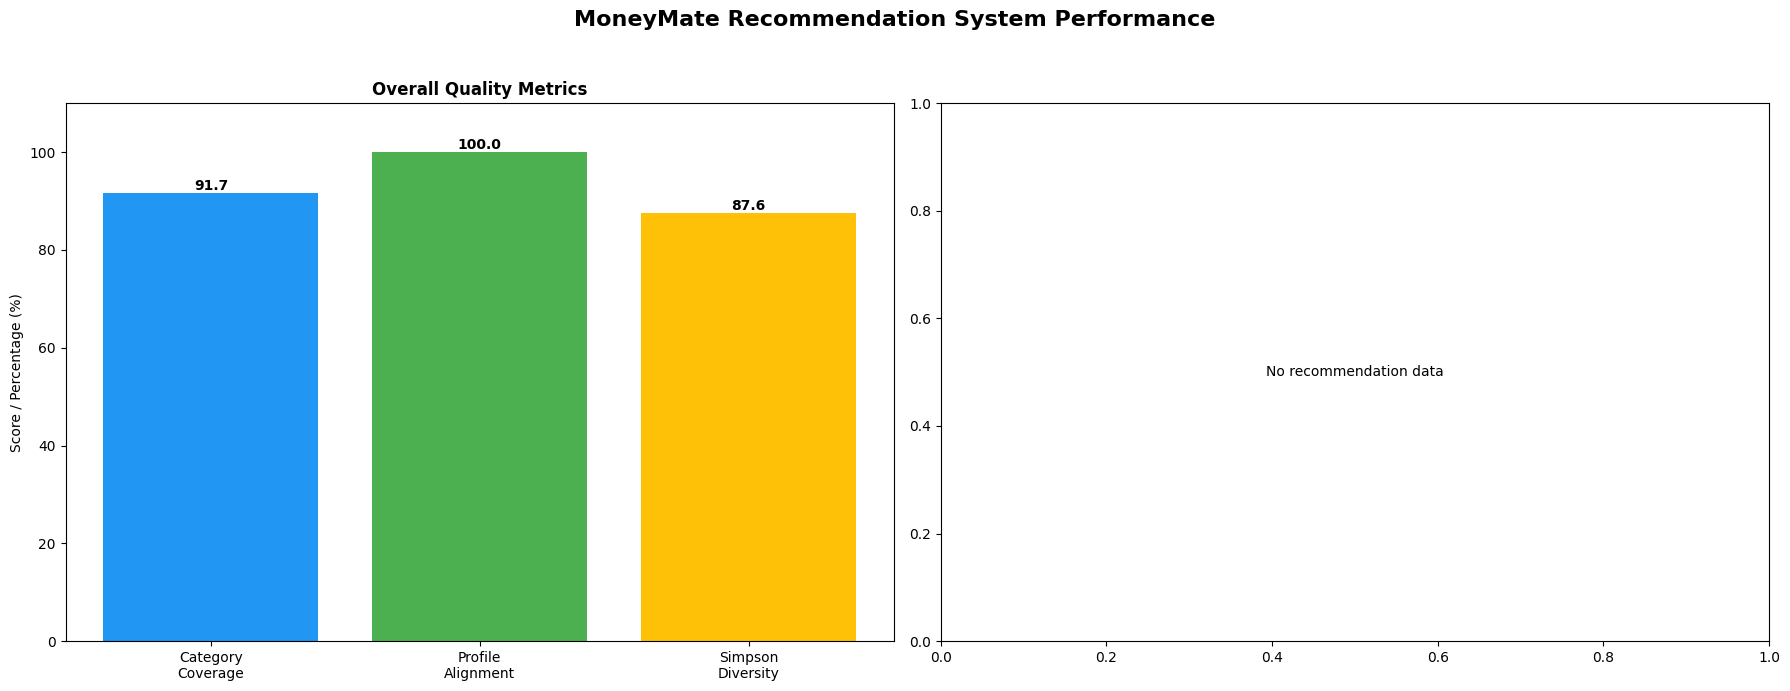

In [ ]:
print("📊 Creating Performance Visualizations...")

if evaluation_results:
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    fig.suptitle('MoneyMate Recommendation System Performance', fontsize=16, fontweight='bold')

    # Plot 1: Key Performance Metrics
    metrics_to_plot = {
        'Category\nCoverage': evaluation_results.get('coverage_metrics', {}).get('category_coverage', 0) * 100,
        'Profile\nAlignment': evaluation_results.get('personalization_metrics', {}).get('profile_alignment_score', 0) * 100,
        'Simpson\nDiversity': evaluation_results.get('diversity_metrics', {}).get('simpson_diversity', 0) * 100
    }

    colors = ['#2196F3', '#4CAF50', '#FFC107']
    bars = axes[0].bar(metrics_to_plot.keys(), metrics_to_plot.values(), color=colors)
    axes[0].set_title('Overall Quality Metrics', fontweight='bold')
    axes[0].set_ylabel('Score / Percentage (%)')
    axes[0].set_ylim(0, 110)
    for bar in bars:
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2., height, f'{height:.1f}', ha='center', va='bottom', fontweight='bold')

    # Plot 2: Top Recommended Categories
    rec_dist = evaluation_results.get('recommendation_distribution', {})
    if rec_dist:
        sorted_recs = sorted(rec_dist.items(), key=lambda x: x[1], reverse=True)[:7]
        labels, values = zip(*sorted_recs)
        sns.barplot(ax=axes[1], x=list(values), y=list(labels), palette='viridis', orient='h')
        axes[1].set_title('Top 7 Recommended Categories', fontweight='bold')
        axes[1].set_xlabel('Number of Recommendations')
    else:
        axes[1].text(0.5, 0.5, 'No recommendation data', ha='center', va='center')

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()
else:
    print("⚠️ Cannot create visualizations as evaluation results are not available.")

## 💾 Ekspor Model dan Aset untuk Deployment

Setelah sistem rekomendasi dibangun dan dievaluasi, langkah terakhir dalam siklus *machine learning* adalah menyimpan (mengekspor) semua komponen yang diperlukan. Proses ini, yang juga dikenal sebagai serialisasi, memungkinkan kita untuk memuat kembali model dan data yang telah dilatih ke dalam lingkungan lain, seperti server web, tanpa perlu melatih ulang dari awal.

Pada tahap ini, kita akan menyimpan:
1.  **Objek Sistem Rekomendasi (`rec_system`)**: Ini adalah komponen utama yang berisi semua logika, termasuk data tips, objek `StandardScaler` dan `PCA` yang telah dilatih, serta matriks similaritas. Kita akan menggunakan `pickle` untuk menyimpannya.
2.  **DataFrame Fitur Pengguna (`user_features_df`)**: Data ini penting untuk analisis cepat profil pengguna dan akan disimpan dalam format CSV agar mudah dibaca atau di-debug jika diperlukan.
3.  **Daftar Kolom Fitur**: Menyimpan nama-nama kolom yang digunakan untuk pelatihan model agar konsisten saat membuat prediksi baru.
4.  **File `requirements.txt`**: File ini mencantumkan semua pustaka Python yang dibutuhkan agar aplikasi web dapat berjalan dengan benar.

Dengan mengekspor aset-aset ini, tim *backend/frontend* dapat dengan mudah mengintegrasikan model ke dalam aplikasi MoneyMate.

In [ ]:
print("🚀 Starting model and asset export process...")

# Tentukan direktori untuk menyimpan aset
export_dir = 'moneymate_assets'
if not os.path.exists(export_dir):
    os.makedirs(export_dir)
    print(f"✅ Directory '{export_dir}' created.")

# 1. Simpan objek sistem rekomendasi utama
try:
    model_path = os.path.join(export_dir, 'moneymate_rec_system.pkl')
    with open(model_path, 'wb') as f:
        pickle.dump(rec_system, f)
    print(f"✅ Recommendation system saved to: {model_path}")
except Exception as e:
    print(f"❌ Failed to save model: {e}")

# 2. Simpan file requirements.txt
try:
    requirements_path = os.path.join(export_dir, 'requirements.txt')
    # Gunakan versi yang sesuai dengan lingkungan Anda jika memungkinkan
    requirements = [
        "pandas",
        "numpy",
        "scikit-learn",
        "fastapi",
        "uvicorn[standard]",
    ]
    with open(requirements_path, 'w') as f:
        f.write("\n".join(requirements))
    print(f"✅ requirements.txt file created at: {requirements_path}")
except Exception as e:
    print(f"❌ Failed to create requirements.txt: {e}")

print("\n📦 All assets have been exported and are ready for web integration.")

🚀 Starting model and asset export process...
✅ Directory 'moneymate_assets' created.
✅ Recommendation system saved to: moneymate_assets/moneymate_rec_system.pkl
✅ requirements.txt file created at: moneymate_assets/requirements.txt

📦 All assets have been exported and are ready for web integration.
